In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
train_set = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train_features.pkl')

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import pickle

In [4]:
train_model = train_set.dropna(subset=['sales_lag_1', 'sales_lag_7', 'rolling_mean_7']).copy()
train_model['days_since_launched'] = train_model['days_since_launched'].fillna(0)
train_model = train_model.drop(columns=['launch_date'])


numeric_features = ['sales_lag_1', 'sales_lag_7', 'rolling_mean_7', 'Month', 'Year',
                     'is_weekend', 'is_launched', 'days_since_launched']
categorical_features = ['family']

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough'
)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))
])

X_train_raw = train_model[numeric_features + categorical_features]
y_train = train_model['sales']


In [5]:
pipeline.fit(X_train_raw, y_train)

with open('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/pipeline_model.pkl', 'wb') as f:
  pickle.dump(pipeline, f)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [6]:
test_set = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/test_set.pkl')

In [7]:
test_model = test_set.dropna(subset = ['sales_lag_1', 'sales_lag_7', 'rolling_mean_7']).copy()
test_model['days_since_launched'] = test_model['days_since_launched'].fillna(0)
test_model = test_model.drop(columns =['launch_date'])

x_test_raw = test_model[numeric_features + categorical_features]

In [8]:
print(x_test_raw.shape)
x_test_raw

(162162, 9)


,sales_lag_1,sales_lag_7,rolling_mean_7,Month,Year,is_weekend,is_launched,days_since_launched,family
2838726,3.000,2.000,3.714286,5,2017,0,1,1596.0,AUTOMOTIVE
2838727,0.000,0.000,0.000000,5,2017,0,0,0.0,BABY CARE
2838728,2.000,6.000,4.000000,5,2017,0,1,1596.0,BEAUTY
2838729,2393.000,2033.000,2036.571429,5,2017,0,1,1596.0,BEVERAGES
2838730,0.000,0.000,0.142857,5,2017,0,1,216.0,BOOKS
...,...,...,...,...,...,...,...,...,...
3000883,56.155,73.289,68.802571,8,2017,0,1,1686.0,POULTRY
3000884,147.000,86.000,87.285714,8,2017,0,1,1686.0,PREPARED FOODS
3000885,585.615,790.013,655.629857,8,2017,0,1,1321.0,PRODUCE
3000886,0.000,0.000,0.000000,8,2017,0,1,1140.0,SCHOOL AND OFFICE SUPPLIES


In [9]:
with open('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/pipeline_model.pkl', 'rb') as f:
  pipeline = pickle.load(f)

In [10]:
test_model['predicted_sales'] = pipeline.predict(x_test_raw)

In [11]:
print(test_model.shape)
print(test_model.columns)
test_model

(162162, 17)
Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'sales_lag_1', 'sales_lag_7', 'rolling_mean_7', 'Month', 'Year',
       'is_weekend', 'is_launched', 'days_since_launched', 'naive_pred',
       'ma_pred', 'predicted_sales'],
      dtype='object')


,id,date,store_nbr,family,sales,onpromotion,sales_lag_1,sales_lag_7,rolling_mean_7,Month,Year,is_weekend,is_launched,days_since_launched,naive_pred,ma_pred,predicted_sales
2838726,2838726,2017-05-17,1,AUTOMOTIVE,2.000,0,3.000,2.000,3.714286,5,2017,0,1,1596.0,3.000,3.714286,3.615159
2838727,2838727,2017-05-17,1,BABY CARE,0.000,0,0.000,0.000,0.000000,5,2017,0,0,0.0,0.000,0.000000,0.000000
2838728,2838728,2017-05-17,1,BEAUTY,5.000,1,2.000,6.000,4.000000,5,2017,0,1,1596.0,2.000,4.000000,3.773168
2838729,2838729,2017-05-17,1,BEVERAGES,2374.000,31,2393.000,2033.000,2036.571429,5,2017,0,1,1596.0,2393.000,2036.571429,2027.562210
2838730,2838730,2017-05-17,1,BOOKS,1.000,0,0.000,0.000,0.142857,5,2017,0,1,216.0,0.000,0.142857,1.206976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000751,2017-08-15,54,POULTRY,59.619,0,56.155,73.289,68.802571,8,2017,0,1,1686.0,56.155,68.802571,72.619754
3000884,3000752,2017-08-15,54,PREPARED FOODS,94.000,0,147.000,86.000,87.285714,8,2017,0,1,1686.0,147.000,87.285714,86.529998
3000885,3000753,2017-08-15,54,PRODUCE,915.371,76,585.615,790.013,655.629857,8,2017,0,1,1321.0,585.615,655.629857,730.205471
3000886,3000754,2017-08-15,54,SCHOOL AND OFFICE SUPPLIES,0.000,0,0.000,0.000,0.000000,8,2017,0,1,1140.0,0.000,0.000000,1.206976


In [12]:
daily_comparision = test_model.groupby('date')[['sales', 'predicted_sales']].sum().reset_index()

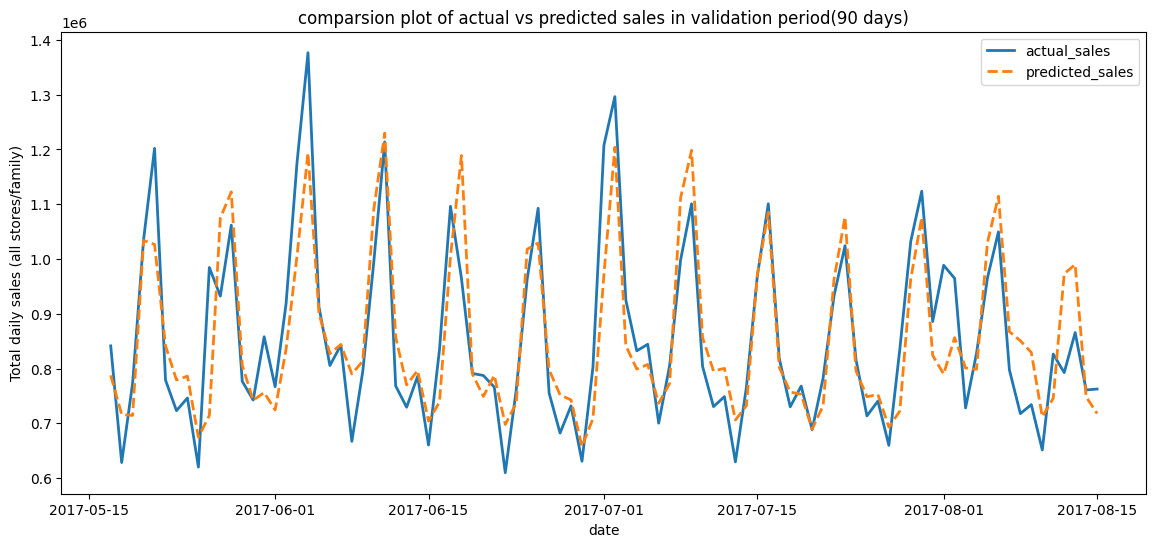

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize = (14,6))
plt.plot(daily_comparision['date'], daily_comparision['sales'], label = 'actual_sales', linewidth = 2)
plt.plot(daily_comparision['date'], daily_comparision['predicted_sales'], label = 'predicted_sales', linewidth =2, linestyle = '--')
plt.xlabel('date')
plt.ylabel('Total daily sales (all stores/family)')
plt.title('comparsion plot of actual vs predicted sales in validation period(90 days)')
plt.legend()
plt.show()

In [15]:
daily_comparision['error'] = daily_comparision['predicted_sales'] - daily_comparision['sales']
print(daily_comparision['error'].mean())
print(daily_comparision['error'].describe())

1023.3372750617909
count        91.000000
mean       1023.337275
std       86999.248240
min     -269961.107153
25%      -46368.765563
50%       10747.264706
75%       58354.712920
max      223709.246938
Name: error, dtype: float64


In [17]:
print(daily_comparision['sales'].mean())
print(daily_comparision['predicted_sales'].mean())

855310.4173207141
856333.754595776
